In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def generate_navigation_inputs(num_steps=10000, arena_size=(1.0, 1.0), proj_dim=100):
    """
    Simulate an animal exploring a square arena.
    Each step: sample position (x,y), direction theta,
    distance to wall along direction, then random nonlinear projection.
    Returns:
      - projected: Tensor of shape (num_steps, proj_dim)
      - positions: NumPy array of shape (num_steps, 2)
    """
    # Sample positions uniformly in the arena
    positions = np.random.rand(num_steps, 2) * np.array(arena_size)
    headings = np.random.rand(num_steps) * 2 * np.pi

    # Compute distance to nearest wall along heading direction
    dx = np.cos(headings)
    dy = np.sin(headings)
    dist_x = np.where(dx > 0,
                      (arena_size[0] - positions[:, 0]) / dx,
                      -positions[:, 0] / dx)
    dist_y = np.where(dy > 0,
                      (arena_size[1] - positions[:, 1]) / dy,
                      -positions[:, 1] / dy)
    dist = np.minimum(dist_x, dist_y)

    # Raw features: x, y, sin(theta), cos(theta), dist
    features = np.stack([positions[:, 0], positions[:, 1],
                         np.sin(headings), np.cos(headings), dist], axis=1)

    # Random nonlinear projection
    W = np.random.randn(features.shape[1], proj_dim) * 0.5
    projected = np.tanh(features.dot(W))
    return torch.tensor(projected, dtype=torch.float32), positions

In [3]:
def train_model(model, data, criterion_fn, optimizer, epochs=20, batch_size=128, plot=True):
    """
    Generic training loop for any autoencoder model.

    Args:
      model: an nn.Module returning (reconstruction, hidden) on forward(x)
      data: Tensor of shape (N, D)
      criterion_fn: function(model, batch, recon, hidden) -> loss tensor
      optimizer: torch optimizer initialized on model.parameters()
      epochs: number of epochs
      batch_size: mini-batch size

    Returns:
      Trained model
    """
    loader = torch.utils.data.DataLoader(data, batch_size=batch_size, shuffle=True)
    pbar = tqdm(range(epochs), desc="Training Autoencoder", unit="epoch")
    loss_curve = []
    for _ in pbar:
        total_loss = 0.0
        for batch in loader:
            optimizer.zero_grad()
            recon, hidden = model(batch)
            loss = criterion_fn(model, batch, recon, hidden)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * batch.size(0)
        pbar.set_postfix(loss=total_loss / len(data))
        loss_curve.append(total_loss / len(data))
    
    if plot:
        plt.figure(figsize=(5, 3))
        plt.plot(loss_curve)
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training Loss Curve")
        plt.show()
    
    return model

In [4]:
def plot_place_maps(z, positions, resolution=50, figsize=None, title=None, avg=True):
    """ 
    Plot place maps for each hidden unit in a grid layout.
    Args:
        z: Tensor of shape (T, H) with compressed codes
        positions: NumPy array of shape (T, 2) with x,y positions
        resolution: number of bins for histogram
    """
    
    # determine grid size
    H = z.shape[1]
    grid_n = int(np.ceil(np.sqrt(H)))
    resolution = resolution

    fig, axes = plt.subplots(grid_n, grid_n, 
                             figsize=(grid_n*2, grid_n*2) if figsize is None else figsize, 
                             sharex=True, 
                             sharey=True)
    x = positions[:, 0]
    y = positions[:, 1]

    # for each hidden unit
    for idx in range(grid_n * grid_n):
        row = idx // grid_n
        col = idx % grid_n
        ax = axes[row, col]
        if idx < H:
            act = z[:, idx]
            # compute mean activation map
            sum_act, xedges, yedges = np.histogram2d(
                x, y, bins=resolution, range=[[0,1],[0,1]], weights=act)
            count, _, _ = np.histogram2d(x, y, bins=resolution, range=[[0,1],[0,1]])
            place_map = sum_act / (count + 1e-6) if avg else sum_act
            im = ax.imshow(
                place_map.T, origin='lower', extent=(0,1,0,1), interpolation='nearest'
            )
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_xlabel('X positions')
            ax.set_ylabel('Y positions')
            ax.set_title(f'Hidden Unit {idx+1}')
        else:
            ax.axis('off')
    plt.suptitle(title if title else "")
    plt.tight_layout()
    plt.show()

In [5]:
data, positions = generate_navigation_inputs(num_steps=20000, proj_dim=100)
data.shape, positions.shape

(torch.Size([20000, 100]), (20000, 2))

## KL Sparsity

In [6]:
class SparseAutoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, sparsity_target=0.05, beta=1e-3):
        super().__init__()
        self.encoder = nn.Linear(input_dim, hidden_dim)
        self.decoder = nn.Linear(hidden_dim, input_dim)
        self.sparsity_target = sparsity_target
        self.beta = beta

    def forward(self, x):
        z = torch.sigmoid(self.encoder(x))  # hidden activations in [0,1]
        x_hat = self.decoder(z)
        return x_hat, z

    def sparsity_loss(self, z):
        # average activation per hidden unit
        rho_hat = torch.clamp(z.mean(dim=0), 1e-6, 1-1e-6)
        rho = self.sparsity_target
        # KL divergence term
        kl = rho * torch.log(rho / rho_hat) + (1-rho) * torch.log((1-rho)/(1-rho_hat))
        return kl.sum()

Training Autoencoder: 100%|██████████| 300/300 [00:26<00:00, 11.49epoch/s, loss=0.0093] 


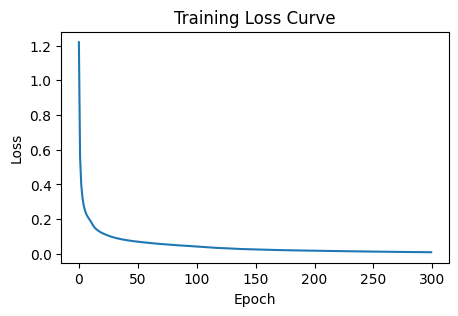

In [7]:
# train
sparse_model = SparseAutoencoder(input_dim=100, hidden_dim=25, sparsity_target=0.001, beta=1e-1)
optimizer_s = optim.Adam(sparse_model.parameters(), lr=1e-3)
# define sparse loss
def sparse_criterion(model, x, recon, hidden):
    mse = nn.MSELoss()(recon, x)
    return mse + model.beta * model.sparsity_loss(hidden)

sparse_model = train_model(sparse_model, data, sparse_criterion, optimizer_s, epochs=300, batch_size=256, plot=True)

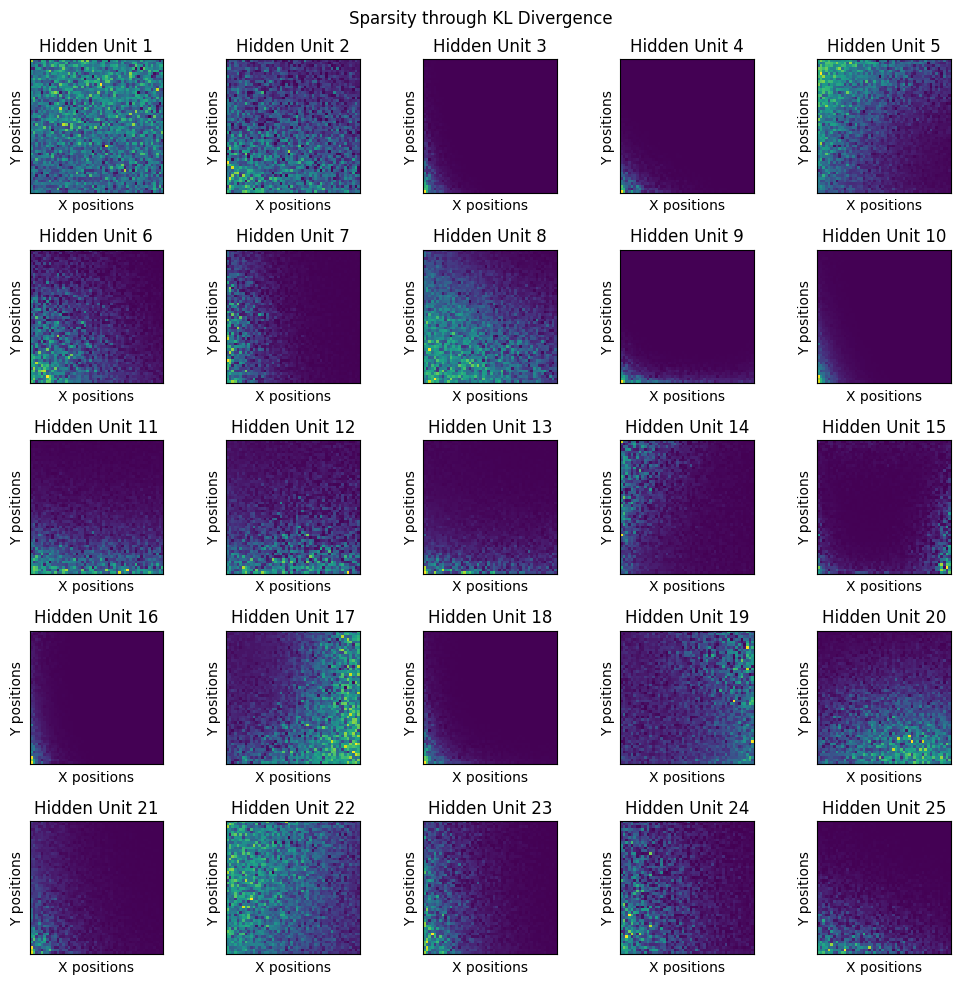

In [8]:
x_hat, z = sparse_model(data)

plot_place_maps(z.detach().numpy(), positions, resolution=50,
                title="Sparsity through KL Divergence")

## Binary sparsity

In [9]:
class BinaryAutoencoder(nn.Module):
    """
    Two-layer autoencoder with binary hidden units via straight-through estimator.
    """
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.encoder = nn.Linear(input_dim, hidden_dim)
        self.decoder = nn.Linear(hidden_dim, input_dim)

    def forward(self, x):
        # real-valued probability
        z_prob = torch.sigmoid(self.encoder(x))
        # hard binary code
        z_hard = (z_prob > 0.5).float()
        # straight-through estimator: forward uses z_hard, gradient flows through z_prob
        z = z_hard + (z_prob - z_prob.detach())
        x_hat = self.decoder(z)
        return x_hat, z

Training Autoencoder: 100%|██████████| 100/100 [00:07<00:00, 12.96epoch/s, loss=0.00563]


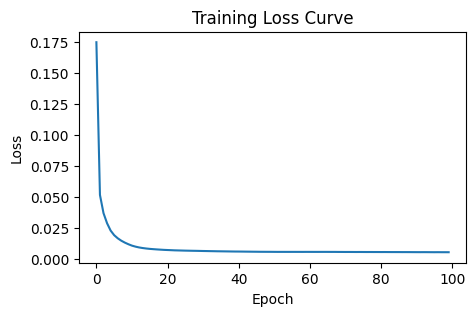

In [10]:
binary_model = BinaryAutoencoder(input_dim=100, hidden_dim=25)
optimizer_b = optim.Adam(binary_model.parameters(), lr=1e-3)
# define binary loss
def binary_criterion(model, x, recon, hidden):
    return nn.MSELoss()(recon, x)

binary_model = train_model(binary_model, data, binary_criterion, optimizer_b, epochs=100, batch_size=256, plot=True)

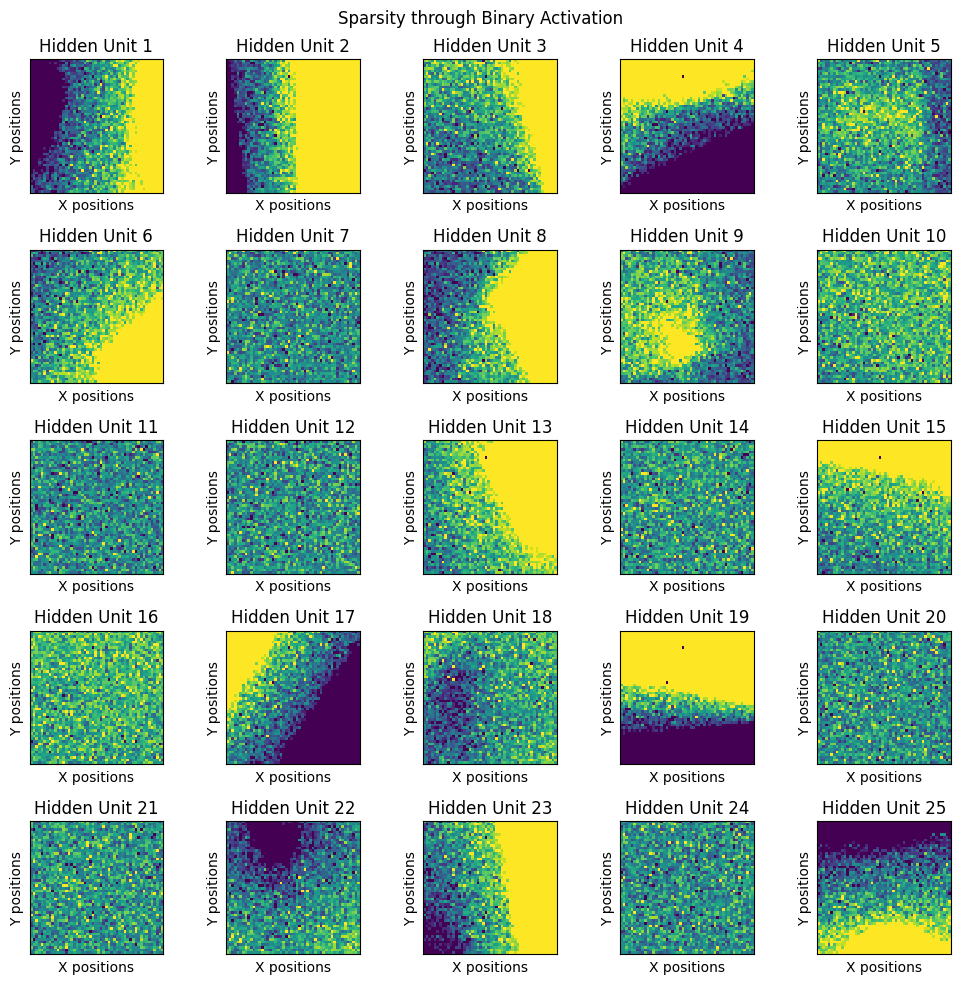

In [11]:
x_hat, z = binary_model(data)
plot_place_maps(z.detach().numpy(), positions,
                title="Sparsity through Binary Activation")

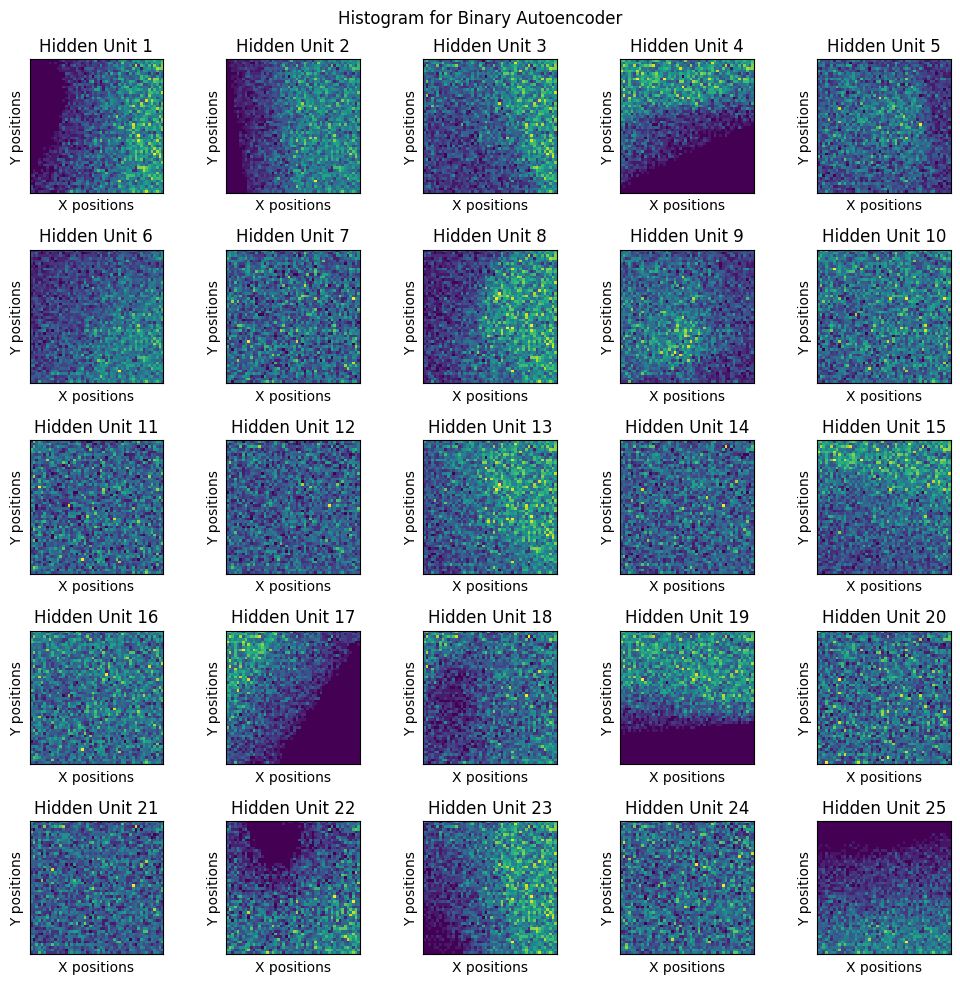

In [12]:
plot_place_maps(z.detach().numpy(), positions,
                      title="Histogram for Binary Autoencoder",
                      resolution=50, avg=False)

In [13]:
z.detach().numpy().sum(axis=0)

array([10773., 13925., 13205.,  9007., 10816., 13902.,  9625., 13624.,
       12113., 12828.,  9530., 10154., 15711., 10644., 14261., 12940.,
        7786., 10067., 12029., 10392., 10550.,  7710., 13609.,  9997.,
        9446.], dtype=float32)

## Top-K Binary sparsity

In [14]:
class KBinaryAutoencoder(nn.Module):
    """
    Two-layer autoencoder with binary hidden units via straight-through estimator.
    """
    def __init__(self, input_dim, hidden_dim, k=4):
        super().__init__()
        self.encoder = nn.Linear(input_dim, hidden_dim)
        self.decoder = nn.Linear(hidden_dim, input_dim)
        self.k = k

    def forward(self, x):
        # real-valued probability
        z_prob = torch.sigmoid(self.encoder(x))
        
        # find the top-k indices per example
        topk_vals, topk_idx = z_prob.topk(k=self.k, dim=1)
        
        # make a zero‐mask and set the winners to 1
        mask = torch.zeros_like(z_prob)
        # mask[i, j] = 1 if j is one of the top-k for example i
        mask.scatter_(1, topk_idx, 1.0)
            
        # straight-through: forward uses mask, gradient flows via z_prob
        z = mask + (z_prob - z_prob.detach())
        x_hat = self.decoder(z)
        return x_hat, z

Training Autoencoder: 100%|██████████| 1000/1000 [01:20<00:00, 12.47epoch/s, loss=0.0502]


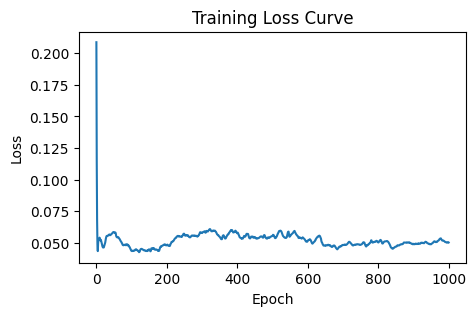

In [15]:
k_binary_model = KBinaryAutoencoder(input_dim=100, hidden_dim=25, k=2)
optimizer_b = optim.Adam(k_binary_model.parameters(), lr=1e-3)
# define binary loss
def binary_criterion(model, x, recon, hidden):
    return nn.MSELoss()(recon, x)

k_binary_model = train_model(k_binary_model, data, binary_criterion, optimizer_b, epochs=1000, batch_size=256, plot=True)

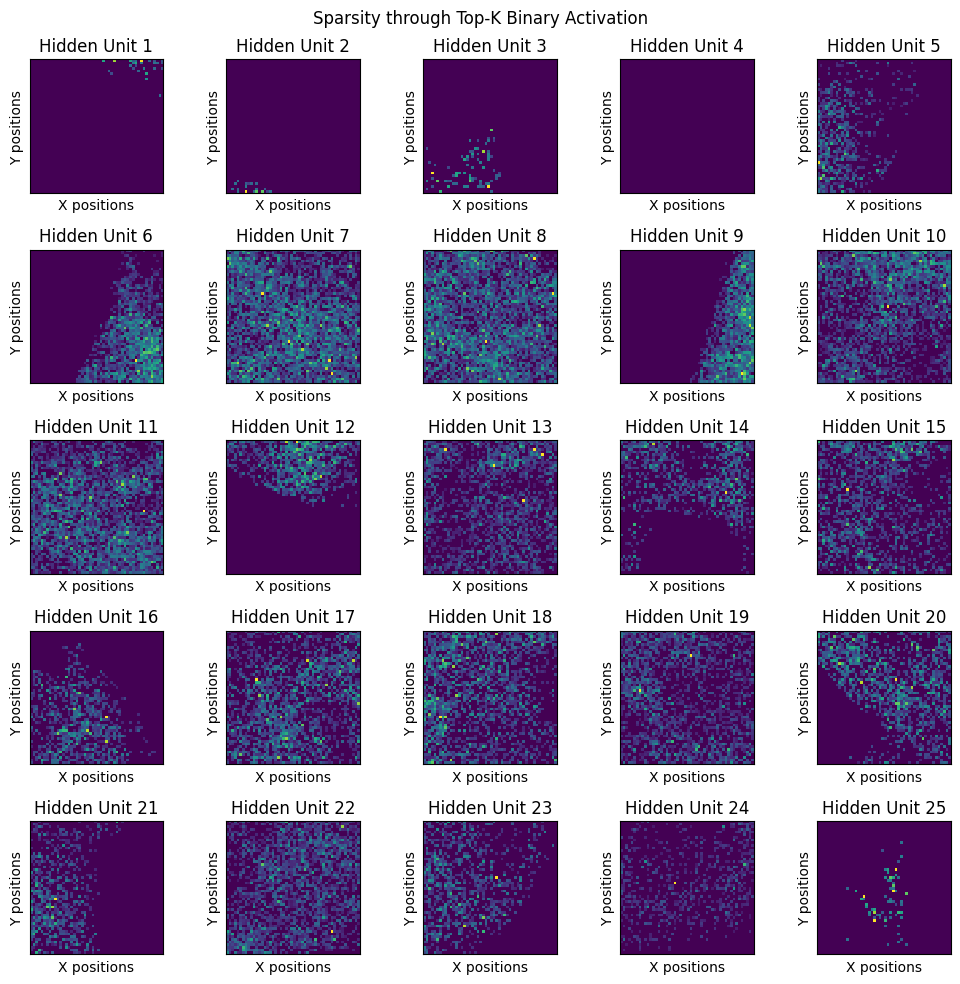

In [16]:
x_hat, z = k_binary_model(data)
plot_place_maps(z.detach().numpy(), positions, resolution=50,
                title="Sparsity through Top-K Binary Activation")

## Beta–Bernoulli Sparse Coder

In [17]:
import pymc as pm
import arviz as az
import pytensor.tensor as pt

In [18]:
np_data = data.detach().numpy()

sub_idx = np.random.choice(np_data.shape[0], size=5000, replace=False)
X = np_data[sub_idx]
pos_sub = positions[sub_idx]

# 2) Build PyMC model: continuous relaxation of Beta-Bernoulli sparse coding
n_samples, D = X.shape
K = 25  # latent dimension

In [ ]:
with pm.Model() as model:
    π = pm.Beta('π', alpha=1, beta=20, shape=K)
    W = pm.Normal('W', mu=0, sigma=1, shape=(D, K))
    
    # linear score + bias → sigmoid
    μz = pm.math.dot(X, W)                      # shape (n,K)
    logitπ = pm.math.log( π / (1-π) )
    z_prob = pm.Deterministic('z_prob',
                              pm.math.sigmoid(μz + logitπ))
    
    # decode & likelihood
    X_hat = pm.math.dot(z_prob, W.T)
    pm.Normal('X_obs', mu=X_hat, sigma=0.1, observed=X)
    
    # variational inference (reduce n and steps if needed)
    approx = pm.fit(n=5000, method='advi')
    trace  = approx.sample(200)

/home/nuttidalab/miniconda3/envs/movie/lib/python3.12/site-packages/pytensor/link/c/cmodule.py:2968: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(
WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


Output()

Finished [100%]: Average Loss = 3.3276e+05


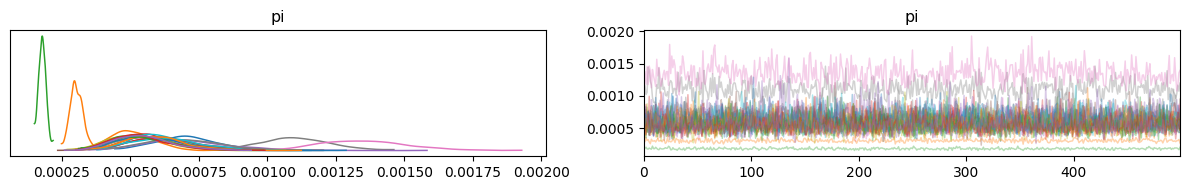

In [39]:
az.plot_trace(trace, var_names=['pi'])
plt.tight_layout()

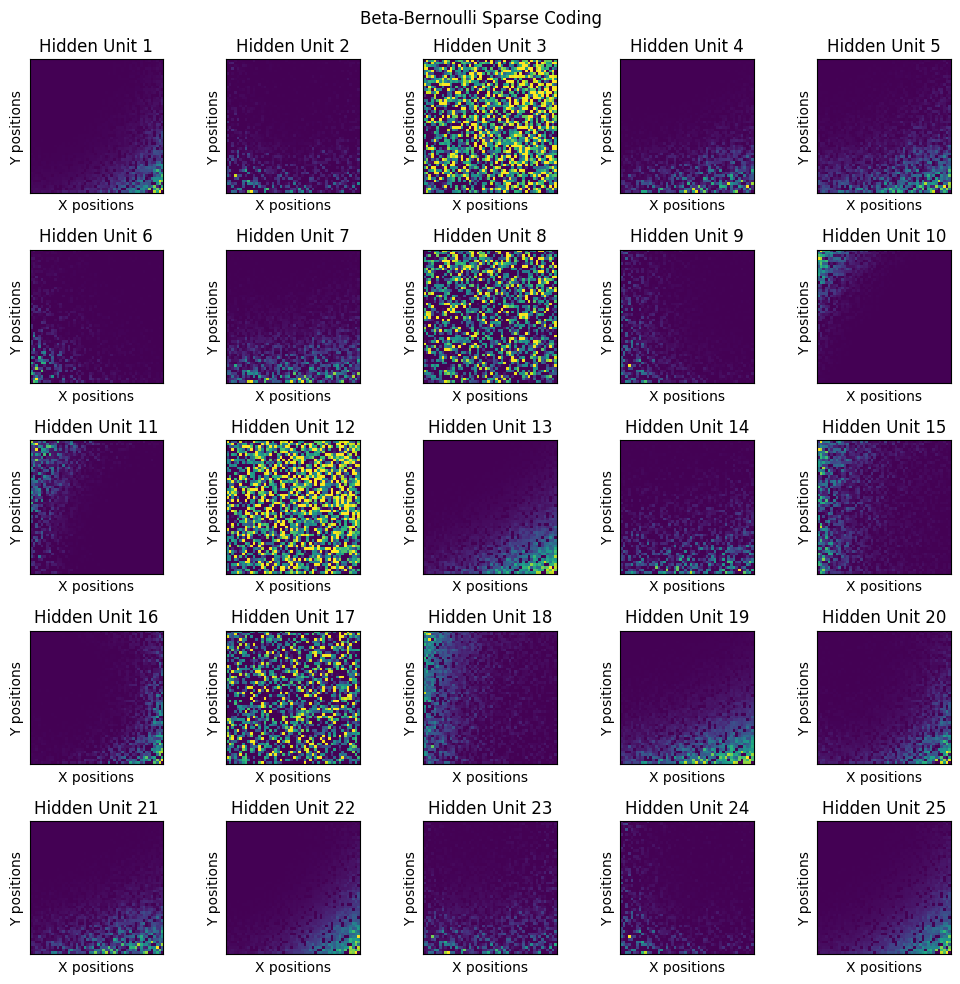

In [36]:
result = trace.posterior["z_prob"].mean(dim=('chain','draw')).values

plot_place_maps(result, pos_sub, resolution=50,
                title="Beta-Bernoulli Sparse Coding")